# 03 — Aprendizado supervisionado com Árvore de Decisão

O objetivo é aprender a classificar novas transações nos três clusters produzidos pelo K-Means.

- **Entradas:** `money`, `hour` e `is_weekend`;
- **Alvo:** `cluster_name`;
- **Divisão:** 80% para treino e 20% para teste, com estratificação;
- **Modelo:** `DecisionTreeClassifier` com profundidade máxima 4;
- **Métricas principais:** acurácia de treino e acurácia de teste.

A árvore foi escolhida porque suas regras podem ser visualizadas. Como o alvo foi criado pelo K-Means a partir do mesmo conjunto de dados, esta etapa aprende uma aproximação da regra de atribuição dos clusters; ela não prevê um fenômeno externo independente.

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "data").is_dir(), "Diretório data não encontrado"


import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
TEST_SIZE = 0.20
MAX_DEPTH = 4
FEATURE_COLS = ["money", "hour", "is_weekend"]
CLUSTER_ORDER = ["Dia útil — manhã", "Dia útil — tarde/noite", "Fim de semana"]
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "coffee_sales_clustered.csv")
assert len(df) == 3636
assert set(df["cluster_name"].unique()) == set(CLUSTER_ORDER)
assert df[FEATURE_COLS].isna().sum().sum() == 0

X = df[FEATURE_COLS]
y = df["cluster_name"]
print(f"Linhas: {len(df)} | Características: {FEATURE_COLS}")
y.value_counts().reindex(CLUSTER_ORDER)

Linhas: 3636 | Características: ['money', 'hour', 'is_weekend']


cluster_name
Dia útil — manhã          1416
Dia útil — tarde/noite    1304
Fim de semana              916
Name: count, dtype: int64

## Separação entre treino e teste

O conjunto de teste fica completamente fora do treinamento. `stratify=y` mantém aproximadamente a mesma proporção dos três clusters nos dois subconjuntos. Árvores de decisão não exigem padronização, pois aprendem limites diretamente nos valores das características.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

assert len(X_train) == 2908
assert len(X_test) == 728

split_summary = pd.DataFrame(
    {
        "treino": y_train.value_counts(),
        "teste": y_test.value_counts(),
    }
).reindex(CLUSTER_ORDER)
split_summary["proporcao_treino"] = split_summary["treino"] / len(y_train)
split_summary["proporcao_teste"] = split_summary["teste"] / len(y_test)

print(f"Treino: {len(X_train)} ({1 - TEST_SIZE:.0%})")
print(f"Teste: {len(X_test)} ({TEST_SIZE:.0%})")
split_summary.round(3)

Treino: 2908 (80%)
Teste: 728 (20%)


,treino,teste,proporcao_treino,proporcao_teste
cluster_name,,,,
Dia útil — manhã,1132,284,0.389,0.390
Dia útil — tarde/noite,1043,261,0.359,0.359
Fim de semana,733,183,0.252,0.251


## Treinamento e acurácias

O modelo Dummy sempre escolhe o cluster mais frequente e funciona como referência mínima. A árvore deve superar essa estratégia ao aprender limites baseados no horário, no fim de semana e no valor da compra.

In [3]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
dummy_test_pred = dummy.predict(X_test)

tree = DecisionTreeClassifier(max_depth=MAX_DEPTH, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)

dummy_accuracy = accuracy_score(y_test, dummy_test_pred)
train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print(f"Acurácia Dummy (teste): {dummy_accuracy:.3%}")
print(f"Acurácia da árvore — treino: {train_accuracy:.3%}")
print(f"Acurácia da árvore — teste:  {test_accuracy:.3%}")
print(f"Acertos no teste: {int((test_pred == y_test).sum())} de {len(y_test)}")

report = pd.DataFrame(
    classification_report(
        y_test,
        test_pred,
        labels=CLUSTER_ORDER,
        output_dict=True,
        zero_division=0,
    )
).T
report.round(3)

Acurácia Dummy (teste): 39.011%
Acurácia da árvore — treino: 97.868%
Acurácia da árvore — teste:  97.390%
Acertos no teste: 709 de 728


,precision,recall,f1-score,support
Dia útil — manhã,0.962,0.972,0.967,284.000
Dia útil — tarde/noite,0.969,0.958,0.963,261.000
Fim de semana,1.000,1.000,1.000,183.000
accuracy,0.974,0.974,0.974,0.974
macro avg,0.977,0.977,0.977,728.000
weighted avg,0.974,0.974,0.974,728.000


## Regras aprendidas

A visualização apresenta as condições usadas pela árvore. Cada caminho da raiz até uma folha forma uma regra de classificação. A importância das características resume quanto cada variável contribuiu para reduzir a mistura entre as classes.

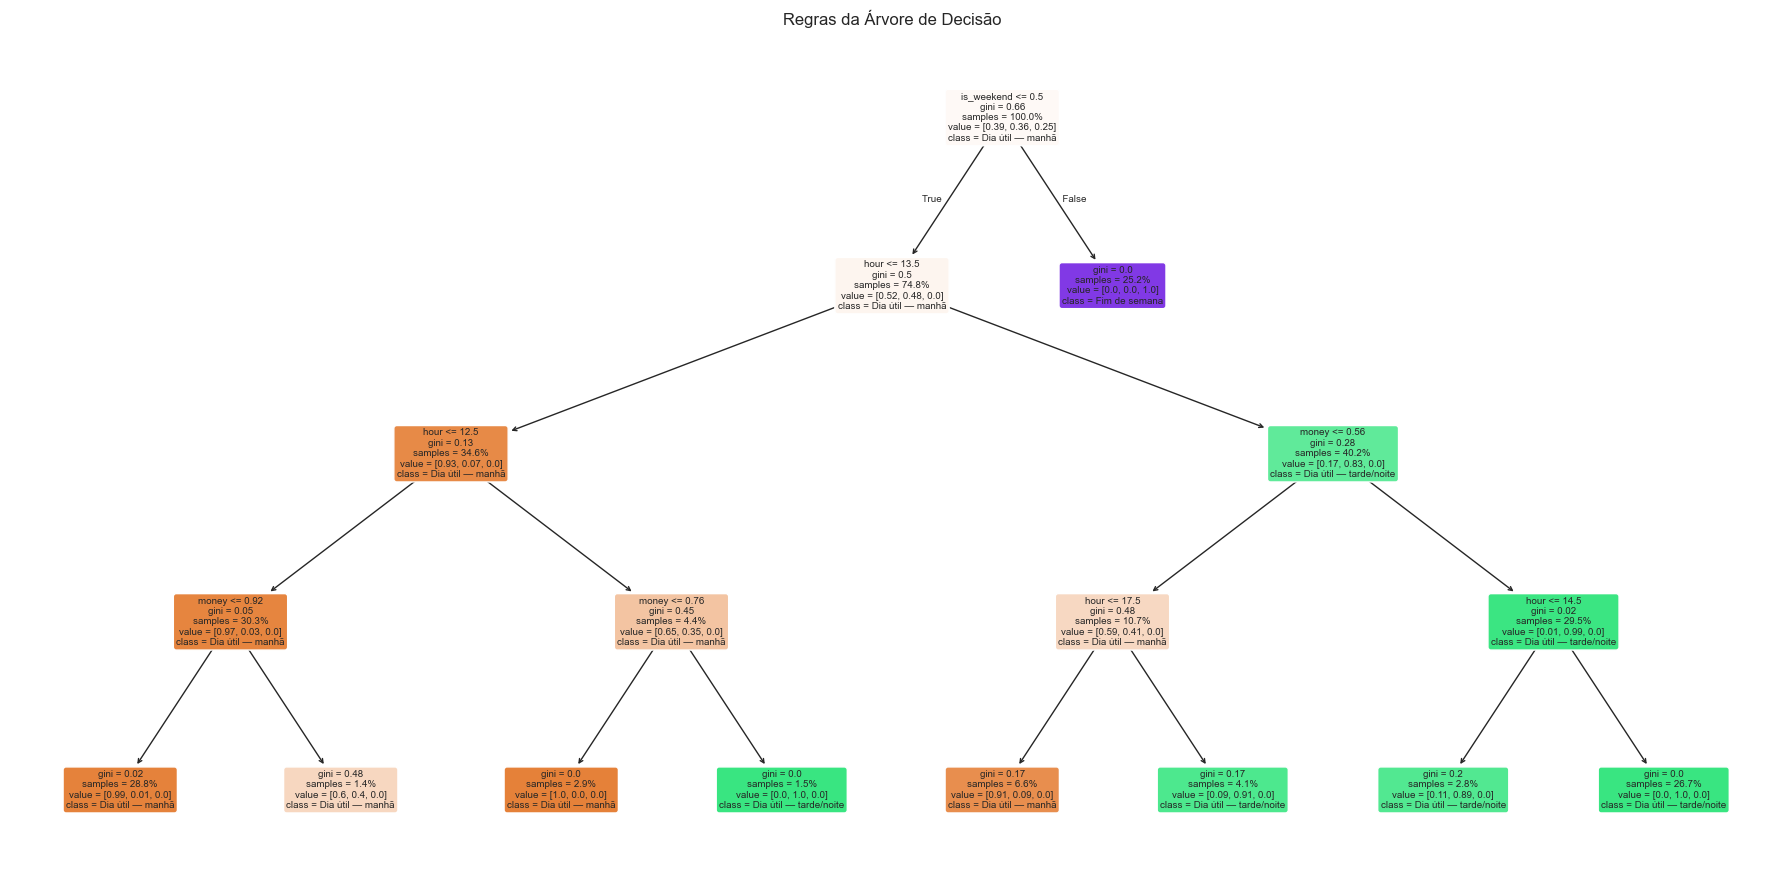

|--- is_weekend <= 0.50
|   |--- hour <= 13.50
|   |   |--- hour <= 12.50
|   |   |   |--- money <= 0.92
|   |   |   |   |--- class: Dia útil — manhã
|   |   |   |--- money >  0.92
|   |   |   |   |--- class: Dia útil — manhã
|   |   |--- hour >  12.50
|   |   |   |--- money <= 0.76
|   |   |   |   |--- class: Dia útil — manhã
|   |   |   |--- money >  0.76
|   |   |   |   |--- class: Dia útil — tarde/noite
|   |--- hour >  13.50
|   |   |--- money <= 0.56
|   |   |   |--- hour <= 17.50
|   |   |   |   |--- class: Dia útil — manhã
|   |   |   |--- hour >  17.50
|   |   |   |   |--- class: Dia útil — tarde/noite
|   |   |--- money >  0.56
|   |   |   |--- hour <= 14.50
|   |   |   |   |--- class: Dia útil — tarde/noite
|   |   |   |--- hour >  14.50
|   |   |   |   |--- class: Dia útil — tarde/noite
|--- is_weekend >  0.50
|   |--- class: Fim de semana



In [4]:
fig, ax = plt.subplots(figsize=(18, 9))
plot_tree(
    tree,
    feature_names=FEATURE_COLS,
    class_names=tree.classes_,
    filled=True,
    rounded=True,
    proportion=True,
    precision=2,
    fontsize=7,
    ax=ax,
)
ax.set_title("Regras da Árvore de Decisão")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "arvore_decisao.png", dpi=180, bbox_inches="tight")
plt.show()

print(export_text(tree, feature_names=FEATURE_COLS, decimals=2))

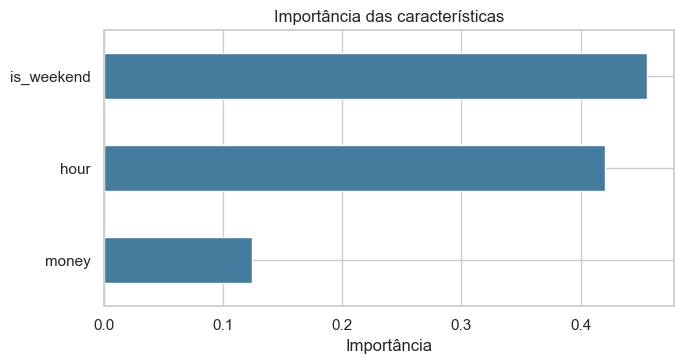

,importance
money,0.124
hour,0.420
is_weekend,0.456


In [5]:
importance = pd.Series(tree.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(7, 3.8))
importance.plot(kind="barh", color="#457B9D", ax=ax)
ax.set_title("Importância das características")
ax.set_xlabel("Importância")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "importancia_caracteristicas.png", dpi=160, bbox_inches="tight")
plt.show()
importance.to_frame("importance").round(3)

## Matriz de confusão

A diagonal mostra os acertos. Valores fora da diagonal representam transações atribuídas ao cluster incorreto no conjunto de teste.

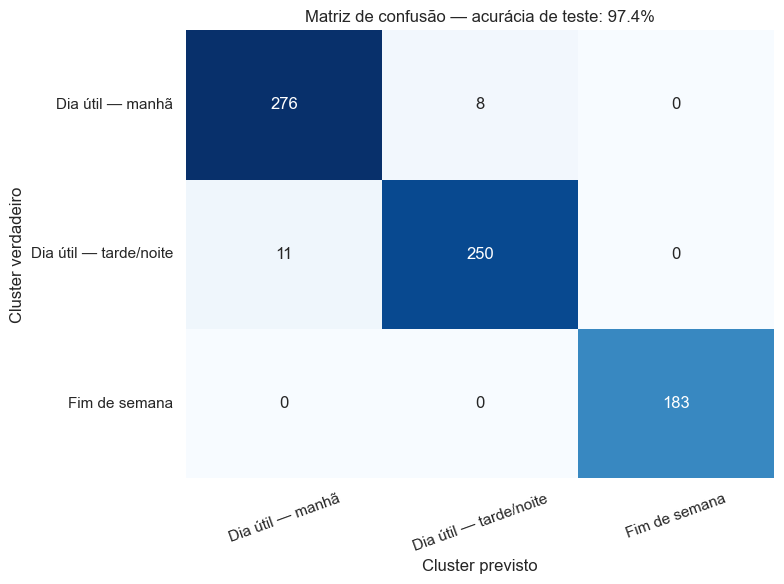

In [6]:
matrix = confusion_matrix(y_test, test_pred, labels=CLUSTER_ORDER)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLUSTER_ORDER,
    yticklabels=CLUSTER_ORDER,
    cbar=False,
    ax=ax,
)
ax.set_title(f"Matriz de confusão — acurácia de teste: {test_accuracy:.1%}")
ax.set_xlabel("Cluster previsto")
ax.set_ylabel("Cluster verdadeiro")
ax.tick_params(axis="x", rotation=20)
ax.tick_params(axis="y", rotation=0)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "matriz_confusao.png", dpi=160, bbox_inches="tight")
plt.show()

In [7]:
predictions = X_test.reset_index(drop=True).copy()
predictions["cluster_true"] = y_test.reset_index(drop=True)
predictions["cluster_pred"] = test_pred
predictions["correct"] = predictions["cluster_true"] == predictions["cluster_pred"]

assert predictions.columns.tolist() == FEATURE_COLS + ["cluster_true", "cluster_pred", "correct"]
assert len(predictions) == 728
assert predictions["correct"].mean() == test_accuracy

output_path = PROJECT_ROOT / "data" / "processed" / "coffee_sales_predictions.csv"
predictions.to_csv(output_path, index=False)
print(f"Arquivo salvo: {output_path} — formato {predictions.shape}")
print(f"Erros no teste: {(~predictions['correct']).sum()}")
predictions.head()

Arquivo salvo: D:\Codigos\Pessoal\IFSP-DataScience\data\processed\coffee_sales_predictions.csv — formato (728, 6)
Erros no teste: 19


,money,hour,is_weekend,cluster_true,cluster_pred,correct
0,0.582267,11,0,Dia útil — manhã,Dia útil — manhã,True
1,0.358318,15,0,Dia útil — manhã,Dia útil — manhã,True
2,0.582267,19,1,Fim de semana,Fim de semana,True
3,0.806216,16,0,Dia útil — tarde/noite,Dia útil — tarde/noite,True
4,0.806216,11,0,Dia útil — manhã,Dia útil — manhã,True


## Conclusão

A comparação entre treino e teste mostra se a árvore generaliza para transações que não participaram do ajuste. A acurácia elevada é esperada porque os rótulos foram criados a partir das mesmas três características. Por isso, o resultado demonstra a capacidade de reproduzir as regras de agrupamento, mas não deve ser interpretado como previsão independente de preferência ou comportamento futuro do cliente.